In [62]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data      # Features
y = digits.target    # Labels

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (1797,)


In [63]:
import sklearn
print(sklearn.__version__)

1.9.0


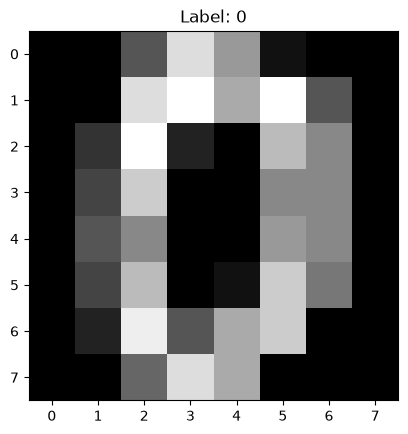

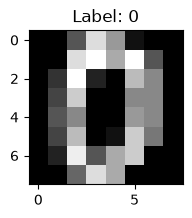

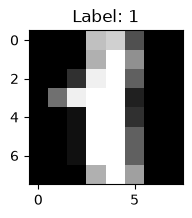

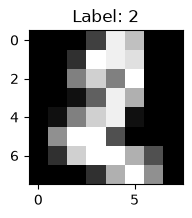

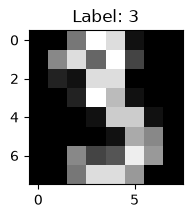

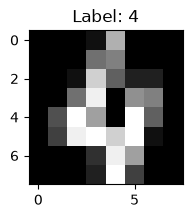

In [64]:
import matplotlib.pyplot as plt

plt.imshow(digits.images[0], cmap="gray")
plt.title(f"Label: {digits.target[0]}")
plt.show()
for i in range(5):
    plt.figure(figsize=(2,2))
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {digits.target[i]}")
    plt.show()

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1437, 64)
(360, 64)


In [66]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [67]:
import sys
print(sys.executable)

d:\AI\ai_env\Scripts\python.exe


In [68]:
import torch
print(torch.__version__)

2.12.0+cpu


In [69]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

In [70]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [71]:
epochs = 100

for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 4.1201
Epoch 10, Loss: 1.6175
Epoch 20, Loss: 0.6161
Epoch 30, Loss: 0.3305
Epoch 40, Loss: 0.2269
Epoch 50, Loss: 0.1731
Epoch 60, Loss: 0.1392
Epoch 70, Loss: 0.1157
Epoch 80, Loss: 0.0979
Epoch 90, Loss: 0.0838


In [72]:
with torch.no_grad():

    outputs = model(X_test)

    _, predicted = torch.max(outputs, 1)

    accuracy = (
        (predicted == y_test)
        .float()
        .mean()
    )

print(
    f"Accuracy: {accuracy.item()*100:.2f}%"
)

Accuracy: 97.22%
